# Interactive Random-Wave Line Scattering

This notebook samples the retained random-wave line network as point scatterers and computes an orientationally averaged 1D scattering curve,

`A(q) = sum_j w_j exp(i q dot r_j)`, `I(q) = |A(q)|^2`.


In [1]:
import importlib

import matplotlib.pyplot as plt
import pyvista as pv
import numpy as np

import rw_line_network as r
import rw_line_scattering as s

r = importlib.reload(r)
s = importlib.reload(s)

print("PyVista", pv.__version__)

PyVista 0.44.0


## Parameters

The random-wave and rendering parameters are assigned on `r`; the scattering-specific parameters are assigned on `s`.

In [2]:
# Random-wave sampling settings
r.GRID_SIZE = 13
r.NUM_BLOCK = 6
r.BLOCK_OVERLAP = 1
r.RANDOM_SEED = 894894
r.NUM_MODES = (64, 64, 64)
r.K_DISTRIBUTION = "gaussian_radial"
r.K0 = (3, 3, 3)
r.r_SIGMA_K = (0.02, 0.02, 0.02)
r.r_K_MIN = (0.98, 0.98, 0.98)
r.r_K_MAX = (1.02, 1.02, 1.02)
r.SHARED_K_VECTORS = False

r.COUPLE_PHI2_PHI3 = True
r.PHI23_COUPLING_C = 1.0

# Vortex tracing settings
r.USE_VORTEX_TRACING = True
r.VORTEX_FACE_PREFILTER = True
r.VORTEX_FACE_ZERO_TOL = 0.02
r.SMOOTH_VORTEX_LINES = True
r.VORTEX_SMOOTHING_SCALE = 2
r.VORTEX_TUBE_RADIUS = 0.25

# Crosslinks are optional point scatterers.
r.CROSSLINK_SEARCH_RADIUS = 1.25
r.CROSSLINK_MERGE_RADIUS = 0.5
r.CROSSLINK_BALL_RADIUS = 1.5

# Render preview settings
r.WINDOW_SIZE = (1000, 1000)
r.CAMERA_ZOOM = 0.82
r.CAMERA_AZIMUTH_DEGREES = 30.0
r.CAMERA_POLAR_DEGREES = 60.0
r.SHOW_BOUNDING_BOX = True
r.BOX_SIZE_L = None

# Scattering settings
s.LINE_SAMPLE_SPACING = 0.5
s.S12_SCATTERING_WEIGHT = 1.0
s.S13_SCATTERING_WEIGHT = 1.0
s.SCATTERING_AMPLITUDE_METHOD = "points"  # "points" or "line_segments"
s.SCATTERING_WINDOW = "hann_box"  # "none", "tukey_box", "hann_box", or "gaussian"
s.SCATTERING_WINDOW_TAPER = 0.15
s.SUBTRACT_WINDOWED_MEAN = False
s.WINDOW_MEAN_METHOD = "numeric_1d"
s.WINDOW_NORMALIZATION = "windowed_measure"
s.SUBTRACT_EXPLICIT_BOX_MEAN = False
s.ANALYTIC_MEAN_BUFFER_BLOCKS = 0
s.ANALYTIC_MEAN_BUFFER_MODE = "none"  # "none", "incoherent", or "coherent"
s.ANALYTIC_MEAN_BUFFER_NORMALIZE_TOTAL = False
s.DYNAMIC_LINE_SAMPLE_SPACING = True
s.DYNAMIC_LINE_SAMPLE_EXPONENT = 0.5
s.DYNAMIC_LINE_SAMPLE_POWER2_SUBSETS = True
s.INCLUDE_CROSSLINK_POINTS = False
s.CROSSLINK_SCATTERING_WEIGHT = 1.0

# Show the actual point scatterers used for I(Q) on the real-space preview.
s.SHOW_STRUCTURE_LINES = False
s.SHOW_SCATTERING_SAMPLE_POINTS = True
s.SCATTERING_SAMPLE_POINTS_AS_BALLS = True
s.SCATTERING_SAMPLE_BALL_RADIUS = 0.35
s.SCATTERING_SAMPLE_POINT_COLOR = "black"
s.SCATTERING_SAMPLE_POINT_SIZE = 2.0
s.SCATTERING_SAMPLE_POINT_OPACITY = 1.0

s.Q_MIN = 0.1
s.Q_MAX = 10
s.NUM_Q = 80
s.Q_SPACING = "log"
s.NUM_Q_DIRECTIONS = 96
s.SCATTERING_SEED = None
s.INTENSITY_NORMALIZATION = "i0"  # "i0", "length_density", or "none"
s.NORMALIZE_I0 = (s.INTENSITY_NORMALIZATION == "i0")
s.Q_AXIS_SCALE = "mean_k"  # "mean_k" or "raw"
s.NUM_SEED_AVERAGE = 4
s.STRUCTURE_SEED_START = r.RANDOM_SEED
s.STRUCTURE_SEED_STRIDE = 1009
s.SCATTERING_FLATTEN_Q_DIRECTIONS = False

print({
    "sampling": {
        "GRID_SIZE": r.GRID_SIZE,
        "NUM_BLOCK": r.NUM_BLOCK,
        "BLOCK_OVERLAP": r.BLOCK_OVERLAP,
        "STITCHED_GRID_SIZE": r.expanded_grid_size(r.GRID_SIZE, r.NUM_BLOCK),
        "K0": r.K0,
        "PHI23_COUPLING_C": r.PHI23_COUPLING_C,
    },
    "scattering": {
        "LINE_SAMPLE_SPACING": s.LINE_SAMPLE_SPACING,
        "SCATTERING_AMPLITUDE_METHOD": s.SCATTERING_AMPLITUDE_METHOD,
        "SCATTERING_WINDOW": s.SCATTERING_WINDOW,
        "SCATTERING_WINDOW_TAPER": s.SCATTERING_WINDOW_TAPER,
        "SUBTRACT_WINDOWED_MEAN": s.SUBTRACT_WINDOWED_MEAN,
        "WINDOW_MEAN_METHOD": s.WINDOW_MEAN_METHOD,
        "WINDOW_NORMALIZATION": s.WINDOW_NORMALIZATION,
        "SUBTRACT_EXPLICIT_BOX_MEAN": s.SUBTRACT_EXPLICIT_BOX_MEAN,
        "ANALYTIC_MEAN_BUFFER_BLOCKS": s.ANALYTIC_MEAN_BUFFER_BLOCKS,
        "ANALYTIC_MEAN_BUFFER_MODE": s.ANALYTIC_MEAN_BUFFER_MODE,
        "ANALYTIC_MEAN_BUFFER_NORMALIZE_TOTAL": s.ANALYTIC_MEAN_BUFFER_NORMALIZE_TOTAL,
        "DYNAMIC_LINE_SAMPLE_SPACING": s.DYNAMIC_LINE_SAMPLE_SPACING,
        "DYNAMIC_LINE_SAMPLE_EXPONENT": s.DYNAMIC_LINE_SAMPLE_EXPONENT,
        "DYNAMIC_LINE_SAMPLE_POWER2_SUBSETS": s.DYNAMIC_LINE_SAMPLE_POWER2_SUBSETS,
        "SHOW_STRUCTURE_LINES": s.SHOW_STRUCTURE_LINES,
        "SHOW_SCATTERING_SAMPLE_POINTS": s.SHOW_SCATTERING_SAMPLE_POINTS,
        "SCATTERING_SAMPLE_POINTS_AS_BALLS": s.SCATTERING_SAMPLE_POINTS_AS_BALLS,
        "SCATTERING_SAMPLE_BALL_RADIUS": s.SCATTERING_SAMPLE_BALL_RADIUS,
        "INCLUDE_CROSSLINK_POINTS": s.INCLUDE_CROSSLINK_POINTS,
        "Q_MIN": s.Q_MIN,
        "Q_MAX": s.Q_MAX,
        "NUM_Q": s.NUM_Q,
        "NUM_Q_DIRECTIONS": s.NUM_Q_DIRECTIONS,
        "INTENSITY_NORMALIZATION": s.INTENSITY_NORMALIZATION,
        "Q_AXIS_SCALE": s.Q_AXIS_SCALE,
        "NUM_SEED_AVERAGE": s.NUM_SEED_AVERAGE,
        "STRUCTURE_SEEDS": s.structure_seed_values(),
    },
})

{'sampling': {'GRID_SIZE': 13, 'NUM_BLOCK': 6, 'BLOCK_OVERLAP': 1, 'STITCHED_GRID_SIZE': 73, 'K0': (3, 3, 3), 'PHI23_COUPLING_C': 1.0}, 'scattering': {'LINE_SAMPLE_SPACING': 0.5, 'SCATTERING_AMPLITUDE_METHOD': 'points', 'SCATTERING_WINDOW': 'hann_box', 'SCATTERING_WINDOW_TAPER': 0.15, 'SUBTRACT_WINDOWED_MEAN': False, 'WINDOW_MEAN_METHOD': 'numeric_1d', 'WINDOW_NORMALIZATION': 'windowed_measure', 'SUBTRACT_EXPLICIT_BOX_MEAN': False, 'ANALYTIC_MEAN_BUFFER_BLOCKS': 0, 'ANALYTIC_MEAN_BUFFER_MODE': 'none', 'ANALYTIC_MEAN_BUFFER_NORMALIZE_TOTAL': False, 'DYNAMIC_LINE_SAMPLE_SPACING': True, 'DYNAMIC_LINE_SAMPLE_EXPONENT': 0.5, 'DYNAMIC_LINE_SAMPLE_POWER2_SUBSETS': True, 'SHOW_STRUCTURE_LINES': False, 'SHOW_SCATTERING_SAMPLE_POINTS': True, 'SCATTERING_SAMPLE_POINTS_AS_BALLS': True, 'SCATTERING_SAMPLE_BALL_RADIUS': 0.35, 'INCLUDE_CROSSLINK_POINTS': False, 'Q_MIN': 0.1, 'Q_MAX': 10, 'NUM_Q': 80, 'NUM_Q_DIRECTIONS': 96, 'INTENSITY_NORMALIZATION': 'i0', 'Q_AXIS_SCALE': 'mean_k', 'NUM_SEED_AVERAGE'

## Build Structure

The structure is generated once and reused for preview and scattering.

In [3]:
structure = s.build_line_structure(
    line_sample_spacing=s.LINE_SAMPLE_SPACING,
    include_crosslinks=s.INCLUDE_CROSSLINK_POINTS,
)

print("sampled scattering points:", len(structure.points))
print("continuous line segments:", len(structure.segment_starts))
print("S12 line points/lines:", structure.s12_lines.n_points, structure.s12_lines.n_lines)
print("S13 line points/lines:", structure.s13_lines.n_points, structure.s13_lines.n_lines)
print("crosslink point scatterers:", len(structure.crosslink_points))

sampled scattering points: 252320
continuous line segments: 504621
S12 line points/lines: 257334 5455
S13 line points/lines: 258317 5575
crosslink point scatterers: 0


## Real-Space Preview

c:\Users\ccu\AppData\Local\miniconda\envs\pyvista\Lib\site-packages\pyvista\core\filters\data_set.py:2386: UserWarning: No vector-like data to use for orient. orient will be set to False.
  warnings.warn("No vector-like data to use for orient. orient will be set to False.")


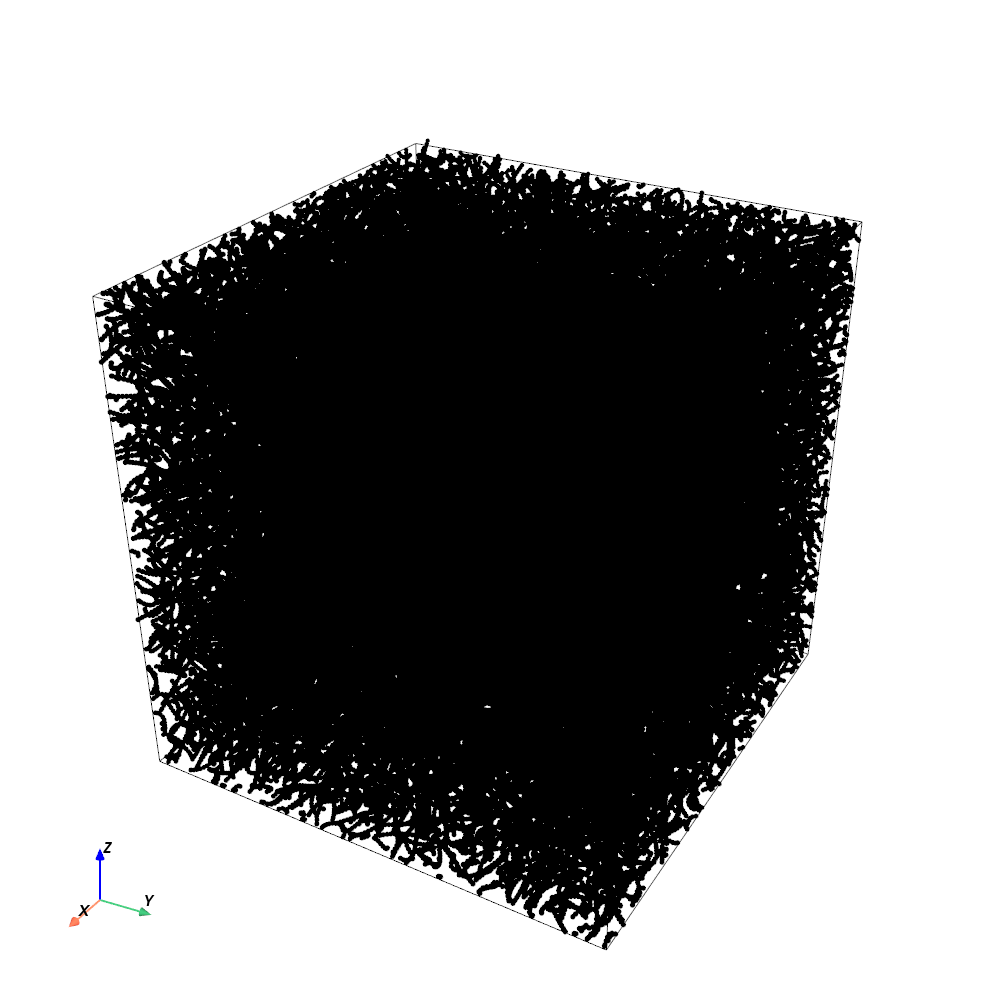

In [4]:
plotter = s.make_structure_plotter(structure)
plotter.show(jupyter_backend="static")

## Scattering Curve

In [5]:
seeds = s.structure_seed_values()
q, iq, iq_std, iq_box, point_counts = s.compute_seed_averaged_scattering(seeds)
k_mean = float(np.mean(r._field_parameter_values(r.K0, "K0")))
block_grid_side = float(r.GRID_SIZE - 1)
q_block_angular = q * block_grid_side
k_wave_angular_mean = 2.0 * np.pi * k_mean
total_line_length = s.total_line_length(structure, weighted=False)
q_scaled_mean_k = q_block_angular / k_wave_angular_mean

if s.Q_AXIS_SCALE == "mean_k":
    q_scaled = q_scaled_mean_k
    q_axis_label = r"$Q_{block}/(2\pi\langle k\rangle)$"
elif s.Q_AXIS_SCALE == "raw":
    q_scaled = q
    q_axis_label = "Q"
else:
    raise ValueError("s.Q_AXIS_SCALE must be 'mean_k' or 'raw'.")


seed 1/4 (894894): fields 1.430s; vortex trace 3.089s; smoothing 3.811s; line point sampling 0.902s; crosslinks 0.000s
seed 1/4 (894894): sampled points 252320 line segments 504621; (S12 125780, S13 126540, crosslinks 0); structure total 9.238s
seed 1/4 (894894): scattering_window=hann_box; scattering_window_taper=0.15; M_windowed=29375; V_windowed=46656; rho_windowed=0.629608; subtract_windowed_mean=False
seed 1/4 (894894): structure 9.240s; scattering sum 39.692s; seed total 48.932s
seed 2/4 (895903): fields 1.532s; vortex trace 3.054s; smoothing 3.879s; line point sampling 0.925s; crosslinks 0.000s
seed 2/4 (895903): sampled points 243589 line segments 504485; (S12 120494, S13 123095, crosslinks 0); structure total 9.398s
seed 2/4 (895903): scattering_window=hann_box; scattering_window_taper=0.15; M_windowed=27618.1; V_windowed=46656; rho_windowed=0.591951; subtract_windowed_mean=False
seed 2/4 (895903): structure 9.402s; scattering sum 37.570s; seed total 46.972s
seed 3/4 (896912):

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5), constrained_layout=True)

ax.plot(q_scaled, iq, color="black", lw=1.6, label="line network")
if len(seeds) > 1:
    ax.fill_between(q_scaled, iq - iq_std, iq + iq_std, color="black", alpha=0.18, linewidth=0)

# ax.plot(q_scaled, iq_box, color="tab:orange", lw=1.4, ls="--", label="box")

ax.set_xlabel(q_axis_label)
ax.set_ylabel("I(Q)")
ax.set_xscale("log")
ax.set_yscale("log")

# ------------------------------------------------------------
# Reference scaling lines: Q^-1 and Q^-4
# ------------------------------------------------------------
q_ref = q_scaled[np.isfinite(iq) & (iq > 0)]
iq_ref = iq[np.isfinite(iq) & (iq > 0)]

# Choose an anchor point inside the plotted range
q0 = np.max(q_ref)
q0 = 5
i0 = np.interp(q0, q_ref, iq_ref)

# Restrict guide lines to a useful Q interval
q_guide = np.logspace(
    np.log10(q_ref.min()),
    np.log10(q_ref.max()),
    200
)

# Scale the guide lines so they pass through (q0, i0)
guide_qm1 = i0 * (q_guide / q0)**(-1)
guide_qm4 = i0 * (q_guide / q0)**(-4)/1000

ax.plot(q_guide, guide_qm1, color="gray", lw=1.2, ls=":", label=r"$Q^{-1}$")
# ax.plot(q_guide, guide_qm4, color="gray", lw=1.2, ls="-.", label=r"$Q^{-4}$")
# ax.set_xlim([0.1, 10.0])
ax.set_ylim([1e-6, 1e-2])

# ------------------------------------------------------------
# Half-box-size marker
# ------------------------------------------------------------
box_l = r.BOX_SIZE_L if r.BOX_SIZE_L is not None else float(r.expanded_grid_size(r.GRID_SIZE, r.NUM_BLOCK) - 1)

# Real-space length = L/2 corresponds to Q = 2*pi / (L/2) = 4*pi/L.
q_half_box = 4.0 * np.pi / box_l

if s.Q_AXIS_SCALE == "mean_k":
    q_half_box_scaled = q_half_box * float(r.GRID_SIZE - 1) / k_wave_angular_mean
elif s.Q_AXIS_SCALE == "raw":
    q_half_box_scaled = q_half_box
else:
    raise ValueError("Unsupported Q axis scale.")

ax.axvline(
    q_half_box_scaled,
    color="tab:red",
    lw=1.2,
    ls="--",
    alpha=0.8,
    label=r"$2\pi/(L/2)$",
)

print("half-box marker:", q_half_box_scaled)

# ------------------------------------------------------------
# FFT-grid q markers: Q_n = 2*pi*n/L_box
# ------------------------------------------------------------
show_fft_q_grid = True
if show_fft_q_grid:
    q_fft_step = 2.0 * np.pi / box_l
    if s.Q_AXIS_SCALE == "mean_k":
        q_fft_step_scaled = q_fft_step * float(r.GRID_SIZE - 1) / k_wave_angular_mean
    elif s.Q_AXIS_SCALE == "raw":
        q_fft_step_scaled = q_fft_step
    else:
        raise ValueError("Unsupported Q axis scale.")

    x_min, x_max = ax.get_xlim()
    if q_fft_step_scaled > 0:
        n_max = int(np.floor(x_max / q_fft_step_scaled))
        for n in range(1, n_max + 1):
            x_fft = n * q_fft_step_scaled
            if x_fft < x_min:
                continue
            ax.axvline(
                x_fft,
                color="0.75",
                lw=0.6,
                ls="-",
                alpha=0.35,
                zorder=0,
                label="FFT q grid" if n == 1 else None,
            )
        print("FFT q-grid step:", q_fft_step_scaled)

ax.legend(frameon=False)
ax.grid(True, alpha=0.25)

print("seeds:", seeds)
print("scattering point counts:", point_counts)
print("mean random-wave k:", k_mean)
print("mean angular wavevector 2*pi*<k>:", k_wave_angular_mean)
print("total line length:", total_line_length)
print("Q axis scale:", s.Q_AXIS_SCALE)
print("scaled Q window shown: 0.1 to 10")
print("I(Q) range:", float(iq.min()), float(iq.max()))


## Save Data

In [7]:
out_path = s.save_scattering_curve(
    s.SCATTERING_OUTPUT_PATH,
    q,
    iq,
    std=iq_std,
    box_intensity=iq_box,
)
print(out_path)

rw_line_scattering_iq.csv
